# 5.1 Model Validation via IRAC Colour Space

This notebook validates the theoretical AGN models by tracking their position within the IRAC colour-colour space and comparing them against the Lacy selection wedge. Results correspond to Section 5.1 of the paper.

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns

# Ensure the project root is in the path to import the local package
sys.path.append(os.path.abspath('..'))

from src import config
from glass import data_io, composite_math, photometry, visualization, analysis

# PASA publication styling
plt.style.use('default')
visualization.apply_pasa_style()
os.makedirs(config.PROCESSED_DATA_DIR, exist_ok=True)

## 1. Load Configurations and Base Models

Loading the filters, AGN SKIRTOR models, and GALSEDATLAS templates.

In [2]:
# Load Filters
filters = photometry.load_passbands(config.FILTER_PATHS)

# Set specific paths for templates
skirtor_dir = config.SKIRTOR_DIR
brown_dir = config.GALSEDATLAS_DIR

# Load AGN Models
agn_type1 = data_io.read_skirtor_model(skirtor_dir, **config.SKIRTOR_TYPE1_PARAMS)
agn_type2 = data_io.read_skirtor_model(skirtor_dir, **config.SKIRTOR_TYPE2_PARAMS)

# Load GALSEDATLAS (Brown) Templates
brown_templates, brown_names = data_io.read_brown_galaxy_templates(brown_dir)

## 2. Generate Composite SEDs and Calculate IRAC Colours

Iterating over the alpha values to calculate composite SEDs for all templates.

In [3]:
# IRAC's four bands sit at fixed OBSERVED wavelengths, so the Lacy wedge is
# an inherently observed-frame diagnostic -- every published application of it
# (Lacy 2004, Stern 2005, Donley 2012) works on observed photometry, not
# rest-frame colours. Evaluating it at z=0 (as an earlier version of this
# notebook did) silently swaps in a different question ("does the intrinsic
# SED shape alone cross this boundary") and both overstates and qualitatively
# distorts the recovered completeness. Instead, each base galaxy template is
# assigned real redshifts bootstrapped from the actual ZFOURGE CIGALE-fit
# sample (datasets/full_zfourge_decomposed/zfourge_full_final.csv, the same
# N=6,509-galaxy population used throughout the paper's empirical sections).
import pandas as pd

RNG_SEED = 42
K_DRAWS = 30  # redshift draws per template, for stable completeness/offset statistics
K_PLOT = 4    # of those K_DRAWS, how many to also carry into the track figure per template

rng = np.random.default_rng(RNG_SEED)
_cigale_csv = os.path.join('..', 'datasets', 'full_zfourge_decomposed', 'zfourge_full_final.csv')
_df_cig = pd.read_csv(_cigale_csv, low_memory=False)
_z_col = 'zpk_x' if 'zpk_x' in _df_cig.columns else 'zpk'
REAL_Z = _df_cig[_z_col].dropna()
REAL_Z = REAL_Z[(REAL_Z > 0) & (REAL_Z < 4)].values
print(f"Real ZFOURGE z distribution: N={len(REAL_Z)}, median={np.median(REAL_Z):.2f}")

results_stats = []  # K_DRAWS rows per (template, AGN type, f_AGN) -- used for completeness/offset tables
results_plot = []   # K_PLOT rows per (template, AGN type, f_AGN) -- used for the track figure

# CIGALE's own discrete fracAGN grid (docs/cigale_decomposition_findings.md,
# paper.tex sec 3.4) -- alpha is DERIVED from it via alpha = f_AGN/(1-f_AGN),
# rather than sweeping alpha and mislabelling the result as "% AGN contribution".
FRAC_AGN_GRID = np.array([0.0, 0.01, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.99])
ALPHA_EXT = FRAC_AGN_GRID / (1.0 - FRAC_AGN_GRID)

for t_idx, gal_sed in enumerate(brown_templates):
    gal_name = brown_names[t_idx]
    print(f"Processing template {t_idx+1}/{len(brown_templates)}: {gal_name}", end='\r')
    # Same K redshift draws reused for both AGN types and every f_AGN step for
    # this template, so a vector offset compares the SAME (template, draw)
    # instance across f_AGN rather than mixing different redshift draws.
    z_draws = rng.choice(REAL_Z, size=K_DRAWS, replace=True)
    # For the track figure, take K_PLOT evenly-spaced order statistics of this
    # template's own draws (not a random subset of them) -- guarantees the
    # plotted tracks span this template's low-to-high assigned redshift rather
    # than risking K_PLOT random picks landing close together by chance.
    sorted_draw_idx = np.argsort(z_draws)
    plot_positions = np.round(np.linspace(0, K_DRAWS - 1, K_PLOT)).astype(int)
    plot_draw_idx = set(sorted_draw_idx[plot_positions])
    for agn_name, agn_model in [('Type1', agn_type1), ('Type2', agn_type2)]:
        for f_agn, alpha in zip(FRAC_AGN_GRID, ALPHA_EXT):
            comp_sed = composite_math.create_composite_sed(agn_model, gal_sed, alpha)
            for draw_idx, z in enumerate(z_draws):
                f5836, f8045 = photometry.calculate_irac_colours(
                    comp_sed, filters['3.6'], filters['4.5'], filters['5.8'], filters['8.0'],
                    redshift=z,
                )
                row = {
                    'Template': gal_name, 'AGN_Type': agn_name, 'f_AGN': f_agn,
                    'Alpha': alpha, 'DrawIdx': draw_idx, 'z': z,
                    'f5836': f5836, 'f8045': f8045,
                }
                results_stats.append(row)
                if draw_idx in plot_draw_idx:
                    results_plot.append(row)

df_results_stats = pd.DataFrame(results_stats)
df_results = pd.DataFrame(results_plot)
print("\nProcessed all composite combinations.")


Real ZFOURGE z distribution: N=10871, median=1.01



Processed all composite combinations.


## 3. Colour Evolution Plots (Fig 1 and 2)

Plotting the IRAC colour evolution tracks. Panels are labelled with a title above each subplot rather than an in-axes annotation.

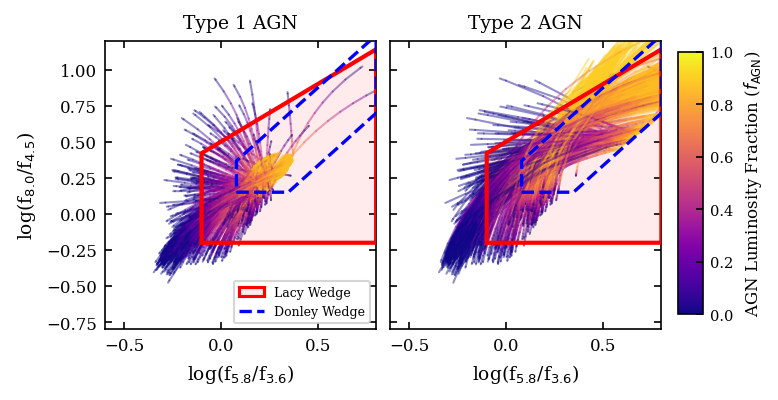

In [4]:
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(5.5, 2.5), sharey=True)
cmap = plt.cm.plasma
norm = plt.Normalize(vmin=0, vmax=1)

for ax, agn_type in [(ax1, 'Type1'), (ax2, 'Type2')]:
    subset = df_results[df_results['AGN_Type'] == agn_type]
    # Group by (Template, DrawIdx) rather than Template alone -- each template
    # now contributes K_PLOT tracks (one per assigned redshift), and each
    # group must still be exactly one row per f_AGN grid point to draw cleanly.
    for (template, draw_idx), temp_df in subset.groupby(['Template', 'DrawIdx']):
        temp_df = temp_df.sort_values('f_AGN')
        xs, ys = temp_df['f5836'].values, temp_df['f8045'].values
        for i in range(len(temp_df) - 1):
            ax.plot(xs[i:i+2], ys[i:i+2], color=cmap(norm(temp_df['f_AGN'].iloc[i])),
                    linewidth=1.0, alpha=0.45, solid_capstyle='round')
    panel_title = 'Type 1 AGN' if agn_type == 'Type1' else 'Type 2 AGN'
    visualization.plot_irac_diagram([], [], ax=ax, title=panel_title)

# Remove duplicate y-axis label and ticks on right panel
ax2.set_ylabel('')

# Legend on left panel only (include Lacy Wedge, remove from ax2)
custom_lines = [
    Patch(facecolor=(1, 0, 0, 0.08), edgecolor='red', lw=1.5, label='Lacy Wedge'),
    Line2D([0], [0], color='blue', linestyle='--', lw=1.6, label='Donley Wedge'),
]
ax1.legend(handles=custom_lines, loc='lower right', fontsize=6)
ax2.get_legend().remove()

# Explicit colorbar axes so it sits flush with the panels
fig.subplots_adjust(wspace=0.05, right=0.80)
cbar_ax = fig.add_axes([0.82, 0.15, 0.03, 0.70])
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label(r'AGN Luminosity Fraction ($f_{\rm AGN}$)', fontsize=8)
cbar.ax.tick_params(labelsize=7)

fig.savefig(os.path.join(config.PROCESSED_DATA_DIR, 'Paper_IRAC_Evolution_Combined.pdf'), dpi=300, bbox_inches='tight')
plt.show()


## 4. Mean Vector Offset Analysis (Table 2)

Calculating the mean vector displacement for IRAC composites and generating a LaTeX table.

In [5]:
def calculate_irac_offsets(df, agn_type):
    subset = df[df['AGN_Type'] == agn_type]
    offsets = []
    for f_agn in subset['f_AGN'].unique():
        f_df = subset[subset['f_AGN'] == f_agn]
        initial_df = subset[subset['f_AGN'] == 0.0]

        x_alpha = f_df['f5836'].values
        y_alpha = f_df['f8045'].values
        x_init = initial_df['f5836'].values
        y_init = initial_df['f8045'].values

        mean_offset = analysis.calculate_mean_vector_offset(x_alpha, y_alpha, x_init, y_init)
        offsets.append({'f_AGN': f_agn, 'Mean_Offset': mean_offset})
    return pd.DataFrame(offsets)

def calculate_irac_completeness(df, agn_type):
    subset = df[df['AGN_Type'] == agn_type]
    out = []
    for f_agn in sorted(subset['f_AGN'].unique()):
        f_df = subset[subset['f_AGN'] == f_agn]
        in_wedge = analysis.is_in_lacy_wedge(f_df['f5836'].values, f_df['f8045'].values)
        out.append({'f_AGN': f_agn, 'Completeness': in_wedge.mean()})
    return pd.DataFrame(out)

# Offsets and completeness use df_results_stats (K_DRAWS x 129 templates per
# f_AGN/type -- see previous cell) for stable statistics; df_results (one
# representative real-redshift draw per template) is used only for the track
# figure above, since 129*K_DRAWS overlapping tracks would be unreadable.
off1 = calculate_irac_offsets(df_results_stats, 'Type1')
off2 = calculate_irac_offsets(df_results_stats, 'Type2')
comp1 = calculate_irac_completeness(df_results_stats, 'Type1')
comp2 = calculate_irac_completeness(df_results_stats, 'Type2')

table_df = pd.DataFrame({
    r'$f_{\rm AGN}$ (\%)': [int(round(f * 100)) for f in FRAC_AGN_GRID],
    'Type 1 Composite': off1['Mean_Offset'].round(2),
    'Type 2 Composite': off2['Mean_Offset'].round(2)
})

display(table_df)
table_df.to_csv(os.path.join(config.PROCESSED_DATA_DIR, 'IRAC_vectoroffset.csv'), index=False)
latex_table = table_df.to_latex(index=False, escape=False,
    caption=r"Mean vector offset from the initial position for both AGN Composite Model Types, as a function of AGN luminosity fraction $f_{\rm AGN}$, for IRAC composites.",
    label="tab:irac_vectoroffset")
with open(os.path.join(config.PROCESSED_DATA_DIR, 'IRAC_vectoroffset.tex'), 'w') as f:
    f.write(latex_table)

completeness_df = pd.DataFrame({
    'f_AGN': comp1['f_AGN'],
    'Type 1 Completeness': comp1['Completeness'].round(3),
    'Type 2 Completeness': comp2['Completeness'].round(3),
})
display(completeness_df)
completeness_df.to_csv(os.path.join(config.PROCESSED_DATA_DIR, 'IRAC_completeness_by_fAGN.csv'), index=False)

print("Exported IRAC Vector Offset and Completeness tables.")


,$f_{\rm AGN}$ (\%),Type 1 Composite,Type 2 Composite
0,0,0.00,0.00
1,1,0.01,0.02
2,10,0.07,0.17
3,20,0.13,0.29
4,30,0.19,0.39
5,40,0.25,0.49
6,50,0.30,0.59
7,60,0.37,0.69
8,70,0.43,0.80
9,80,0.50,0.94


,f_AGN,Type 1 Completeness,Type 2 Completeness
0,0.00,0.226,0.226
1,0.01,0.231,0.239
2,0.10,0.336,0.465
3,0.20,0.493,0.679
4,0.30,0.648,0.837
5,0.40,0.813,0.927
6,0.50,0.920,0.984
7,0.60,0.997,0.997
8,0.70,1.000,0.997
9,0.80,1.000,0.998


Exported IRAC Vector Offset and Completeness tables.


## Export: Paper-Required Figures

Copies the subset of plots referenced by `Context/AGNPaper/paper.tex` into `outputs/PaperFigures/`, so that folder always reflects exactly what the paper needs (see `config.PAPER_FIGURE_MANIFEST`).

In [6]:
# Export the subset of plots required by Context/AGNPaper/paper.tex into
# outputs/PaperFigures/, and - if the gitignored Overleaf checkout is present
# locally - straight into its Images/TheoreticalModelPlots/ folder too, so
# the paper never silently references a stale/missing figure.
# (see config.PAPER_FIGURE_MANIFEST for the full list)
import shutil

os.makedirs(config.PAPER_FIGURES_DIR, exist_ok=True)
overleaf_present = os.path.isdir(config.AGNPAPER_DIR)
if overleaf_present:
    os.makedirs(config.PAPER_OVERLEAF_IMAGES_DIR, exist_ok=True)

copied, missing = [], []
for paper_filename, rel_source in config.PAPER_FIGURE_MANIFEST.items():
    src_path = os.path.join(config.PROCESSED_DATA_DIR, rel_source)
    dst_path = os.path.join(config.PAPER_FIGURES_DIR, paper_filename)
    if os.path.exists(src_path):
        shutil.copy2(src_path, dst_path)
        if overleaf_present:
            shutil.copy2(src_path, os.path.join(config.PAPER_OVERLEAF_IMAGES_DIR, paper_filename))
        copied.append(paper_filename)
    else:
        missing.append(paper_filename)

print(f"Paper figures exported to {config.PAPER_FIGURES_DIR}")
if overleaf_present:
    print(f"  also copied to {config.PAPER_OVERLEAF_IMAGES_DIR}")
print(f"  {len(copied)}/{len(config.PAPER_FIGURE_MANIFEST)} copied")
if missing:
    print("  Still missing (not yet generated by any notebook run):")
    for name in missing:
        print(f"    - {name}")
    print("  Run Paper_Results_Master.ipynb and Model_Validation_via_IRAC.ipynb")
    print("  (both top to bottom) to generate every required source plot.")
else:
    print("  All paper-required figures present.")

Paper figures exported to C:\Users\uqmhooym\OneDrive - The University of Queensland\Documents\GitHub\HonoursResearchProject\outputs\PaperFigures
  also copied to C:\Users\uqmhooym\OneDrive - The University of Queensland\Documents\GitHub\HonoursResearchProject\Context\AGNPaper\Images\TheoreticalModelPlots
  12/12 copied
  All paper-required figures present.
